In [42]:
#---ANALISIS KLASIFIKASI RISIKO PENYAKIT JANTUNG MENGGUNAKAN---#
#---------ALGORITMA DECISION TREE DAN RANDOM FOREST------------#

In [43]:
#---------IMPORT LIBRARY---------#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("images", exist_ok=True)

In [44]:
df = pd.read_csv("heart-disease.csv")

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [47]:
#---------DATA UNDERSTANDING------------#
#===Ukuran Dataset===#

df.shape

(303, 14)

In [48]:
#===Nama Kolom===#

df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [49]:
#===Informasi Dataset===#

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [50]:
#===5 Data Pertama===#

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [51]:
#===Statistik Deskriptif===#

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [52]:
#===Cek Missing Value===#

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [53]:
#===Cek Duplikat===#

df.duplicated().sum()

np.int64(1)

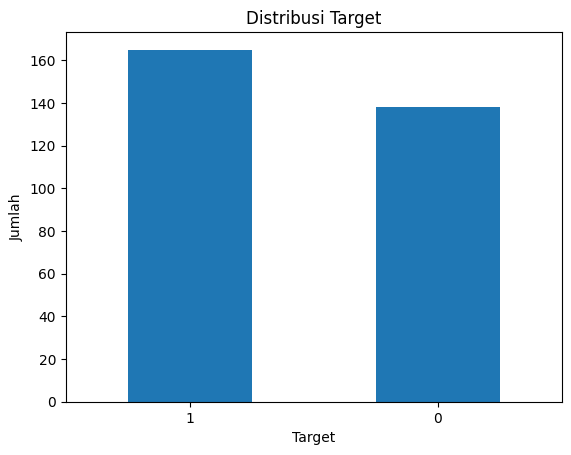

In [54]:
#-------------EXPLORATORY DATA ANALYSIS---------------#
#===Distribusi Dataset===#

df["target"].value_counts()

import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar", rot=0)

plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Jumlah")
plt.savefig("images/target_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

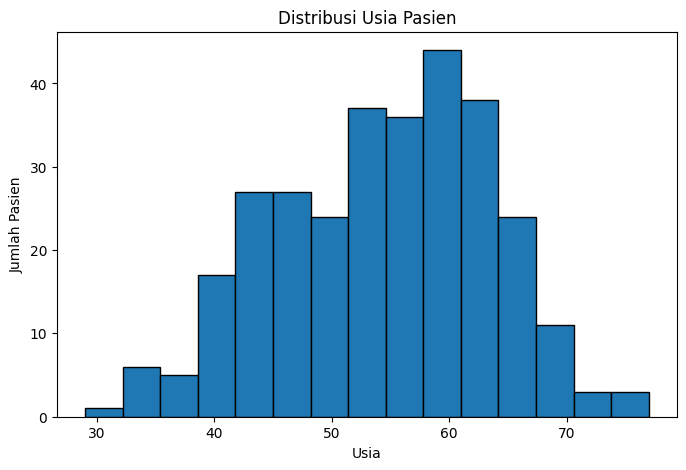

In [55]:
#===Distribusi Usia Pasien===#

plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=15, edgecolor="black")

plt.title("Distribusi Usia Pasien")
plt.xlabel("Usia")
plt.ylabel("Jumlah Pasien")
plt.savefig(
    "images/histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
df["sex"].value_counts()

,count
sex,
1,207
0,96


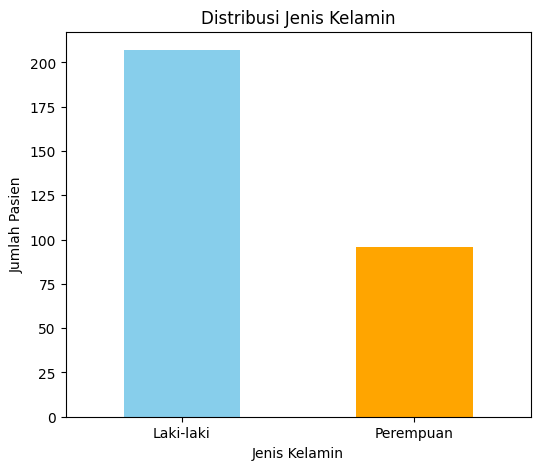

In [57]:
#===Distribusi Jenis Kelamin===#

plt.figure(figsize=(6,5))

df["sex"].value_counts().plot(
    kind="bar",
    color=["skyblue","orange"]
)

plt.title("Distribusi Jenis Kelamin")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Jumlah Pasien")

plt.xticks([0,1],["Laki-laki","Perempuan"], rotation=0)

plt.show()

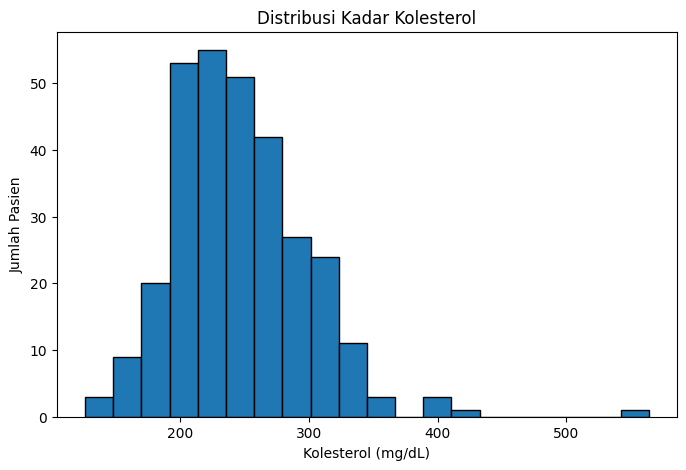

In [58]:
#===Distribusi Kolesterol===#

plt.figure(figsize=(8,5))

plt.hist(df["chol"], bins=20, edgecolor="black")

plt.title("Distribusi Kadar Kolesterol")
plt.xlabel("Kolesterol (mg/dL)")
plt.ylabel("Jumlah Pasien")

plt.show()

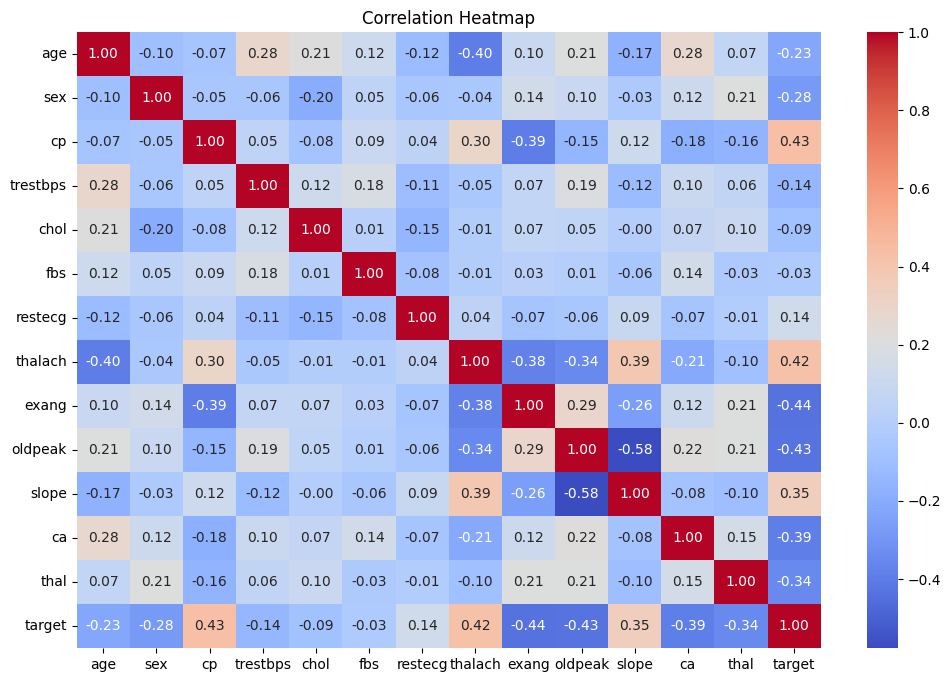

In [59]:
#===Correlation Heatmap===#

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig(
    "images/heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

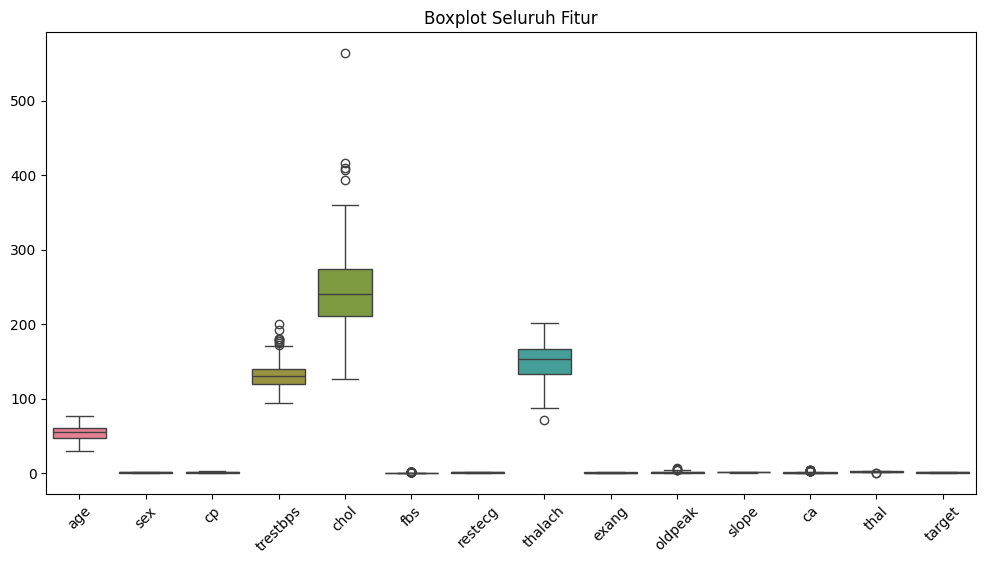

In [60]:
#===Boxplot===#

plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title("Boxplot Seluruh Fitur")
plt.savefig(
    "images/boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

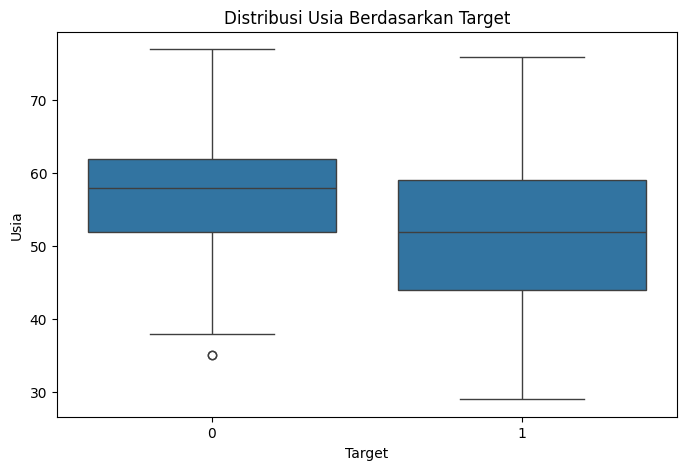

In [61]:
#===Hubungan Umur dengan Target===#

plt.figure(figsize=(8,5))

sns.boxplot(
    x="target",
    y="age",
    data=df
)

plt.title("Distribusi Usia Berdasarkan Target")
plt.xlabel("Target")
plt.ylabel("Usia")

plt.show()

In [62]:
#-----------DATA PREPARATION----------#
#===Memisahkan Fitur dan Target===#

X = df.drop("target", axis=1)
y = df["target"]

print("Jumlah fitur :", X.shape)
print("Jumlah target :", y.shape)

Jumlah fitur : (303, 13)
Jumlah target : (303,)


In [63]:
#===Mengecek Distribusi Target===#

y.value_counts()
print(y.value_counts())

target
1    165
0    138
Name: count, dtype: int64


In [64]:
#===Train Test Split===#

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [65]:
#===Cek Hasil Split===#

print("Training :", X_train.shape)
print("Testing :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training : (242, 13)
Testing : (61, 13)
Training Target : (242,)
Testing Target : (61,)


In [66]:
#--------------------MODELING---------------------#
#===Decision Tree Classifier===#

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [67]:
#===Classification Report: Prediksi, Accuracy, Precision, Recall, F1 Score===#

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Accuracy :", dt_accuracy)

dt_precision = precision_score(y_test, y_pred_dt)
print("Precision :", dt_precision)

dt_recall = recall_score(y_test, y_pred_dt)
print("Recall :", dt_recall)

dt_f1 = f1_score(y_test, y_pred_dt)
print("F1 Score :", dt_f1)

print(classification_report(y_test, y_pred_dt))

Accuracy : 0.7868852459016393
Precision : 0.75
Recall : 0.9090909090909091
F1 Score : 0.821917808219178
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



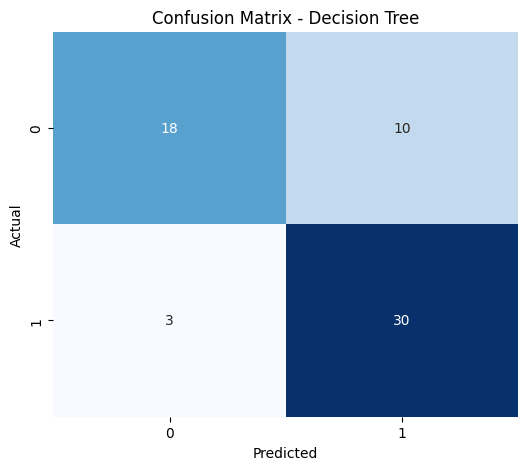

In [68]:
#===Confusion Matrix===#

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig(
    "images/cm_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

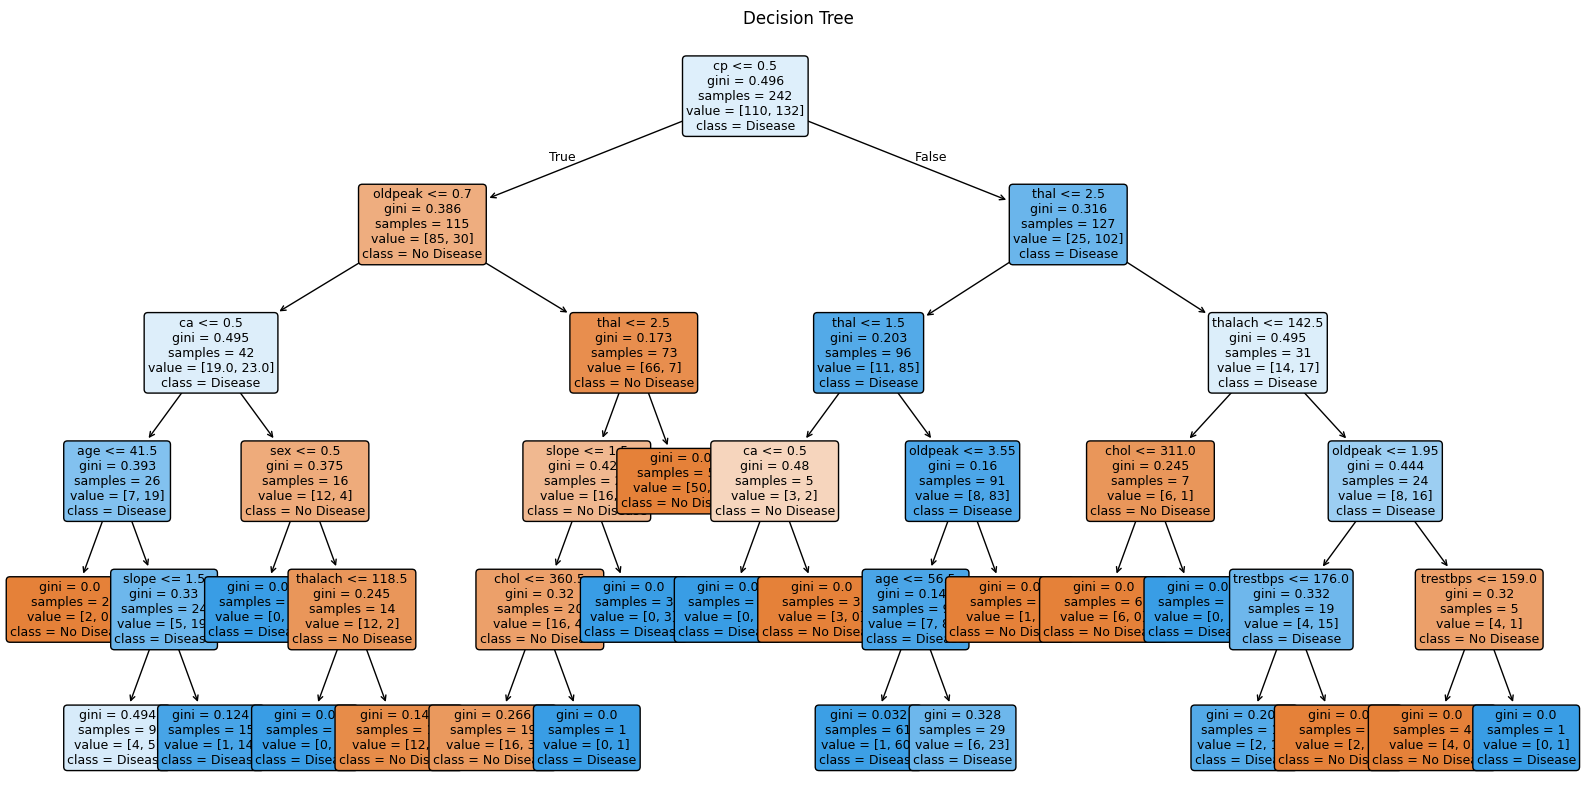

In [69]:
#===Visualisasi Decision Tree===#

from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree")
plt.savefig(
    "images/visual_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

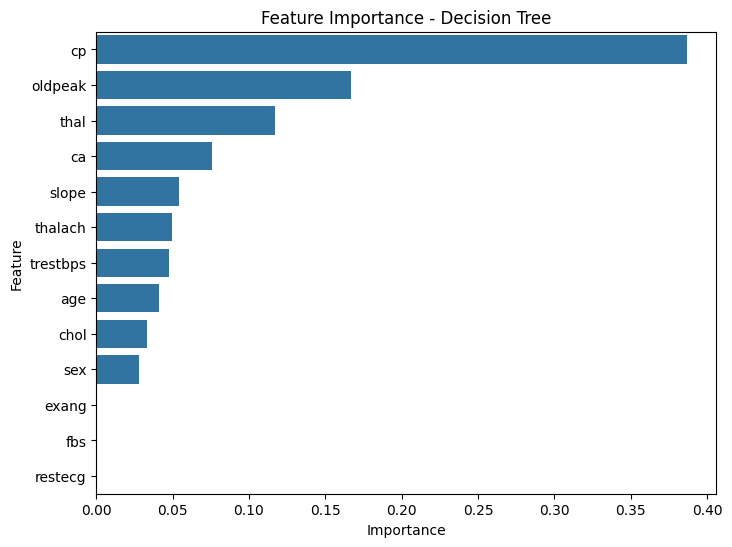

In [70]:
#===Feature Importance===#

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Decision Tree")

plt.show()

In [71]:
#--------------------RANDOM FOREST-------------------#
#===Membangun Model===#

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=5,
    random_state=42
)

In [72]:
#===Melatih Model===#

#Prediksi
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

#Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy :", rf_accuracy)

#Precision
rf_precision = precision_score(y_test, y_pred_rf)
print("Precision :", rf_precision)

#Recall
rf_recall = recall_score(y_test, y_pred_rf)
print("Recall :", rf_recall)

#F1 Score
rf_f1 = f1_score(y_test, y_pred_rf)
print("F1 Score :", rf_f1)

#Classification Report
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.8032786885245902
Precision : 0.7560975609756098
Recall : 0.9393939393939394
F1 Score : 0.8378378378378378
              precision    recall  f1-score   support

           0       0.90      0.64      0.75        28
           1       0.76      0.94      0.84        33

    accuracy                           0.80        61
   macro avg       0.83      0.79      0.79        61
weighted avg       0.82      0.80      0.80        61



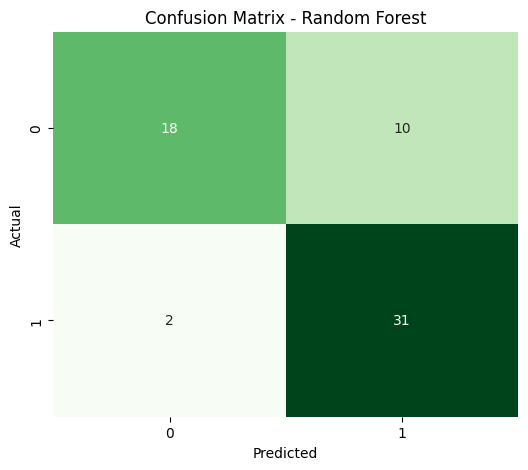

In [73]:
#===Confusion Matrix===#

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(
    "images/cm_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

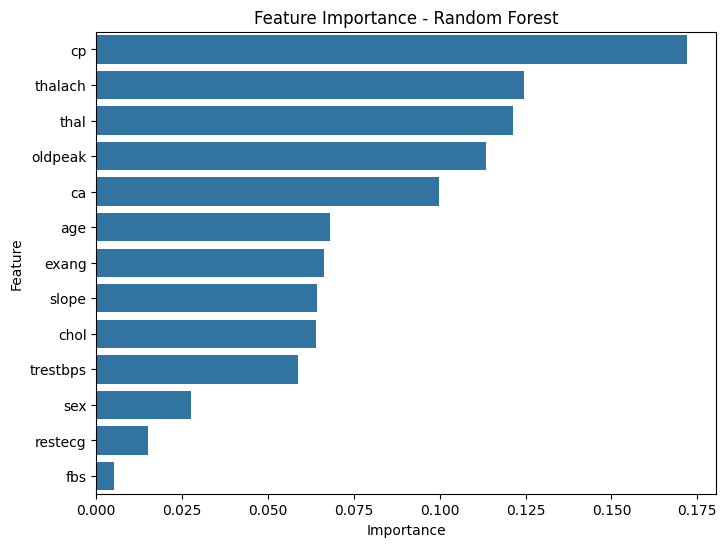

In [74]:
#===Feature Importance===#

importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by="Importance",
    ascending=False
)

importance_rf

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance_rf,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")

plt.show()


In [75]:
#--------------PERBANDINGAN MODEL----------------#

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall],
    "F1-Score": [dt_f1, rf_f1]
})

comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.786885,0.750000,0.909091,0.821918
1,Random Forest,0.803279,0.756098,0.939394,0.837838


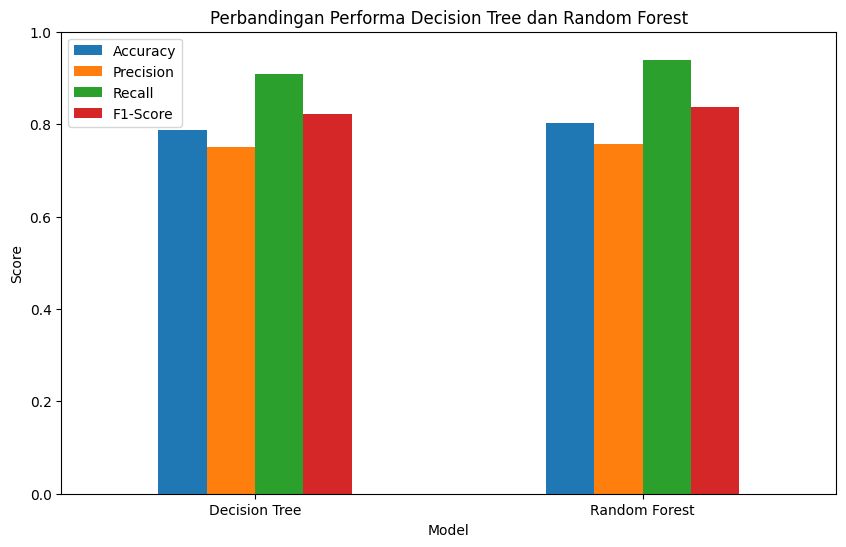

In [76]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Perbandingan Performa Decision Tree dan Random Forest")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()